In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
from pathlib import Path
output_folder = Path("../Graficos")
output_folder.mkdir(parents=True, exist_ok=True)

In [3]:
datos = pd.read_csv("../Datos/Originales/Datos_UX/page_views_2.csv", sep=';')
datos.head()

,event_name,section,user_id,event_date_,event_timestamp_
0,page_view,quiz_work,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:15.062114990
1,page_view,quiz_fit,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:24.243407959
2,page_view,quiz_highlight,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:37.877279053
3,page_view,quiz_bodyShape,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:52.290892090
4,page_view,quiz_eyes,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:58:58.868198975


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794 entries, 0 to 793
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   event_name        794 non-null    object
 1   section           794 non-null    object
 2   user_id           794 non-null    object
 3   event_date_       794 non-null    object
 4   event_timestamp_  794 non-null    object
dtypes: object(5)
memory usage: 31.1+ KB


In [5]:
datos["event_timestamp_"] = pd.to_datetime(datos["event_timestamp_"])
datos["event_date_"] = pd.to_datetime(datos["event_date_"])
datos.head()

,event_name,section,user_id,event_date_,event_timestamp_
0,page_view,quiz_work,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:15.062114990
1,page_view,quiz_fit,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:24.243407959
2,page_view,quiz_highlight,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:37.877279053
3,page_view,quiz_bodyShape,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:52.290892090
4,page_view,quiz_eyes,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:58:58.868198975


In [6]:
datos.shape
datos.user_id.nunique()

41

In [7]:
duplicados = datos.duplicated(subset=['user_id', 'event_timestamp_'], keep='first').sum()
duplicados

np.int64(70)

In [8]:
df_limpio = datos.drop_duplicates(subset=['user_id', 'event_timestamp_'], keep='first')
df_limpio.head()

,event_name,section,user_id,event_date_,event_timestamp_
0,page_view,quiz_work,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:15.062114990
1,page_view,quiz_fit,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:24.243407959
2,page_view,quiz_highlight,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:37.877279053
3,page_view,quiz_bodyShape,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:52.290892090
4,page_view,quiz_eyes,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:58:58.868198975


In [9]:
# Orden lógico del cuestionario
section_order = [
    "quiz_leisure", "quiz_work", "quiz_fit", "quiz_highlight", "quiz_bodyShape",
    "quiz_eyes", "quiz_hair", "quiz_sizes", "quiz_measurements", "quiz_focus",
    "quiz_adventurous", "quiz_styles", "quiz_prices", "quiz_avoid", "quiz_footwear",
    "quiz_you", "quiz_photos", "quiz_social", "quiz_signUp"
]

In [10]:
data = df_limpio
page_order_dict = {page: idx for idx, page in enumerate(section_order)}

In [11]:
# Ordenar el DataFrame por user_id y event_timestamp
data = data.sort_values(by=['user_id', 'event_timestamp_'])

In [12]:
data['from_page'] = data.groupby('user_id')['section'].shift(1)
data['to_page'] = data['section']

In [13]:
def determine_state(row):
    """
    Determina el estado de navegación del usuario en función de las páginas visitadas en un flujo de cuestionario.

    Args:
    row (pd.Series): Una fila de un DataFrame de Pandas que contiene las columnas 'from_page' y 'to_page',
                     representando la página de origen y la página de destino, respectivamente.

    Returns:
    str: Un estado que indica la dirección de la navegación:
         - 'adelante' si el usuario avanza en el flujo del cuestionario.
         - 'atras' si el usuario retrocede en el flujo del cuestionario.
         - 'refresh' si el usuario recarga la misma página.
         - 'otro' si la página de origen o destino no está en el orden predefinido o es NaN.
    """
    section_order = [
    "quiz_leisure", "quiz_work", "quiz_fit", "quiz_highlight", "quiz_bodyShape",
    "quiz_eyes", "quiz_hair", "quiz_sizes", "quiz_measurements", "quiz_focus",
    "quiz_adventurous", "quiz_styles", "quiz_prices", "quiz_avoid", "quiz_footwear",
    "quiz_you", "quiz_photos", "quiz_social", "quiz_signUp"
    ]
    page_order_dict = {page: idx for idx, page in enumerate(section_order)}
    if pd.isna(row['from_page']):
        return 'otro'
    from_idx = page_order_dict.get(row['from_page'], -1)
    to_idx = page_order_dict.get(row['to_page'], -1)
    if from_idx == -1 or to_idx == -1:
        return 'otro'
    if from_idx < to_idx:
        return 'adelante'
    elif from_idx > to_idx:
        return 'atras'
    elif from_idx == to_idx:
        return 'refresh'
    else:
        return 'otro'

In [14]:
# Usamos .apply con axis=1 para que recorra el DataFrame fila por fila
data['navigation_state'] = data.apply(determine_state, axis=1)

# Muestra las primeras filas para ver el resultado
print(data[['user_id', 'from_page', 'to_page', 'navigation_state']].head(10))

                            user_id          from_page            to_page  \
0  040e1e30c9ed4248bc9799a707e36d60                NaN          quiz_work   
1  040e1e30c9ed4248bc9799a707e36d60          quiz_work           quiz_fit   
2  040e1e30c9ed4248bc9799a707e36d60           quiz_fit     quiz_highlight   
3  040e1e30c9ed4248bc9799a707e36d60     quiz_highlight     quiz_bodyShape   
4  040e1e30c9ed4248bc9799a707e36d60     quiz_bodyShape          quiz_eyes   
5  040e1e30c9ed4248bc9799a707e36d60          quiz_eyes          quiz_hair   
6  040e1e30c9ed4248bc9799a707e36d60          quiz_hair         quiz_sizes   
7  040e1e30c9ed4248bc9799a707e36d60         quiz_sizes  quiz_measurements   
8  040e1e30c9ed4248bc9799a707e36d60  quiz_measurements         quiz_focus   
9  040e1e30c9ed4248bc9799a707e36d60         quiz_focus   quiz_adventurous   

  navigation_state  
0             otro  
1         adelante  
2         adelante  
3         adelante  
4         adelante  
5         adelante  
6    

In [15]:
data.head(10)

,event_name,section,user_id,event_date_,event_timestamp_,from_page,to_page,navigation_state
0,page_view,quiz_work,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:15.062114990,NaN,quiz_work,otro
1,page_view,quiz_fit,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:24.243407959,quiz_work,quiz_fit,adelante
2,page_view,quiz_highlight,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:37.877279053,quiz_fit,quiz_highlight,adelante
3,page_view,quiz_bodyShape,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:57:52.290892090,quiz_highlight,quiz_bodyShape,adelante
4,page_view,quiz_eyes,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:58:58.868198975,quiz_bodyShape,quiz_eyes,adelante
5,page_view,quiz_hair,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:59:10.349990967,quiz_eyes,quiz_hair,adelante
6,page_view,quiz_sizes,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:59:20.200894043,quiz_hair,quiz_sizes,adelante
7,page_view,quiz_measurements,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 16:59:59.229868896,quiz_sizes,quiz_measurements,adelante
8,page_view,quiz_focus,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 17:00:02.424375977,quiz_measurements,quiz_focus,adelante
9,page_view,quiz_adventurous,040e1e30c9ed4248bc9799a707e36d60,2025-01-01,2025-01-01 17:00:32.932799072,quiz_focus,quiz_adventurous,adelante


In [16]:
colores = {
    "rojo_suave": "#c66666",
    "turquesa": "#3da490",
    "amarillo": "#e8cc42",
    "salmon": "#f3a486",
    "rojo_fuerte": "#c43d3c",
    "ocre": "#da9d54",
    "fondo": "#f1e4db"
}

C:\Users\Martin\AppData\Local\Temp\ipykernel_14684\4052678495.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conteo_retrocesos, x='section', y='count', palette="Reds_r")


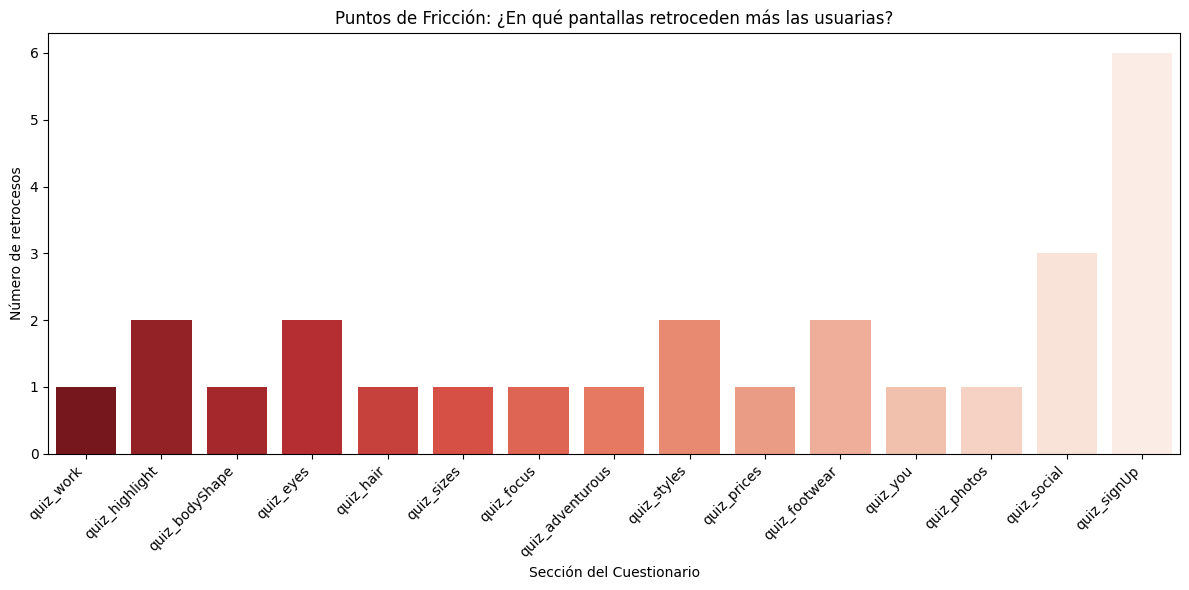

In [17]:
# Filtramos solo los movimientos hacia atrás
retrocesos = data[data['navigation_state'] == 'atras']

# Contamos cuántas veces se retrocede DESDE cada página
conteo_retrocesos = retrocesos['from_page'].value_counts().reset_index()
conteo_retrocesos.columns = ['section', 'count']

# Ordenamos según el flujo del cuestionario para que sea lógico
# (Asegúrate de tener definida la lista section_order como en tu código anterior)
conteo_retrocesos['order'] = conteo_retrocesos['section'].apply(lambda x: section_order.index(x) if x in section_order else -1)
conteo_retrocesos = conteo_retrocesos.sort_values('order')

# Visualización
plt.figure(figsize=(12, 6))
sns.barplot(data=conteo_retrocesos, x='section', y='count', palette="Reds_r")
plt.xticks(rotation=45, ha='right')
plt.title('Puntos de Fricción: ¿En qué pantallas retroceden más las usuarias?')
plt.ylabel('Número de retrocesos')
plt.xlabel('Sección del Cuestionario')
plt.tight_layout()
plt.savefig('../Graficos/Puntos_friccion.png')
plt.show()


In [18]:
df = datos.copy()

In [19]:
df["event_timestamp_"] = pd.to_datetime(df["event_timestamp_"])

# --- Convertir section a categoría ordenada ---
df["section"] = pd.Categorical(df["section"], categories=section_order, ordered=True)

# --- Ordenar eventos ---
df = df.sort_values(["user_id", "event_timestamp_"])

In [20]:
# --- Calcular tiempo hasta la siguiente página ---
df["next_timestamp"] = df.groupby("user_id")["event_timestamp_"].shift(-1)
df["next_section"] = df.groupby("user_id")["section"].shift(-1)

In [21]:
# Tiempo que pasan en cada página
df["time_spent"] = df["next_timestamp"] - df["event_timestamp_"]

In [22]:
# --- Tiempo medio por página ---
avg_time = df.groupby("section")["time_spent"].mean()
print(avg_time)

section
quiz_leisure        1 days 20:50:24.809568706
quiz_work           0 days 00:13:32.205972373
quiz_fit            0 days 00:00:20.415863593
quiz_highlight      0 days 00:00:23.213944607
quiz_bodyShape      0 days 00:00:32.802283291
quiz_eyes           0 days 00:00:10.285764114
quiz_hair           0 days 03:40:40.558493694
quiz_sizes          0 days 00:04:32.125874051
quiz_measurements   0 days 00:02:00.000238082
quiz_focus          0 days 00:00:19.322556980
quiz_adventurous    0 days 00:00:31.065484297
quiz_styles         0 days 00:01:08.720513178
quiz_prices         0 days 00:00:16.158489596
quiz_avoid          0 days 00:00:22.099726283
quiz_footwear       0 days 00:01:18.767331974
quiz_you            0 days 00:00:24.298151535
quiz_photos         0 days 00:07:10.074862723
quiz_social         0 days 00:00:20.037491461
quiz_signUp         1 days 03:34:37.633708806
Name: time_spent, dtype: timedelta64[ns]


C:\Users\Martin\AppData\Local\Temp\ipykernel_14684\3705430750.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time = df.groupby("section")["time_spent"].mean()


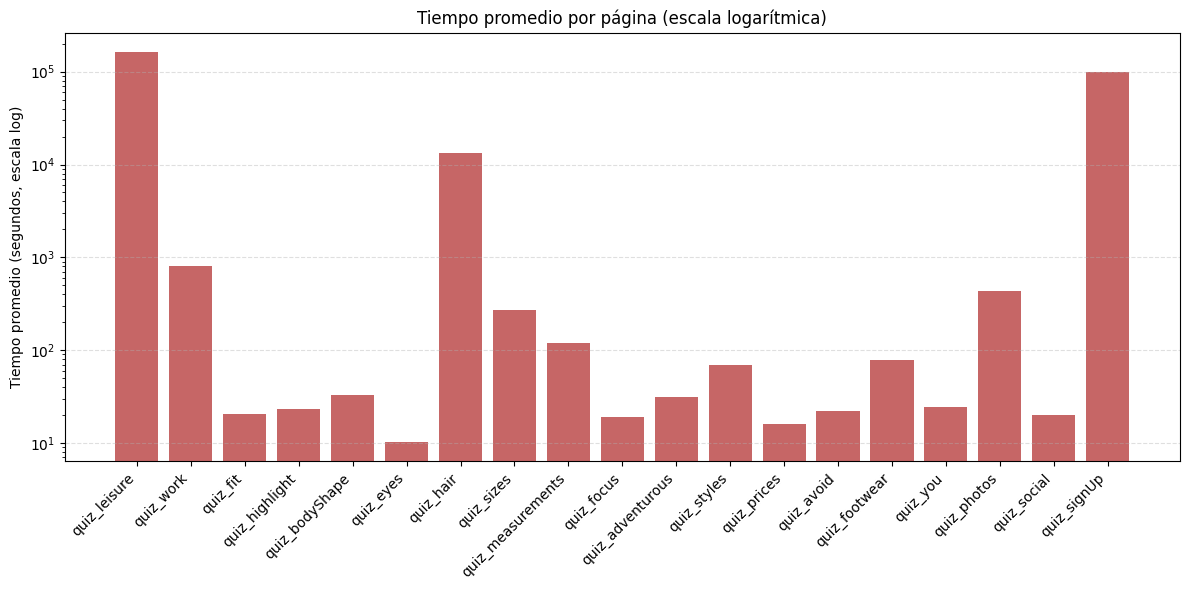

In [23]:
times_seconds = avg_time.dt.total_seconds().reindex(section_order)

plt.figure(figsize=(12, 6))
plt.bar(section_order, times_seconds, color= "#c66666")
plt.yscale("log") 
plt.ylabel("Tiempo promedio (segundos, escala log)")
plt.title("Tiempo promedio por página (escala logarítmica)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig('../Graficos/Tiempo_promedio.png')
plt.show()

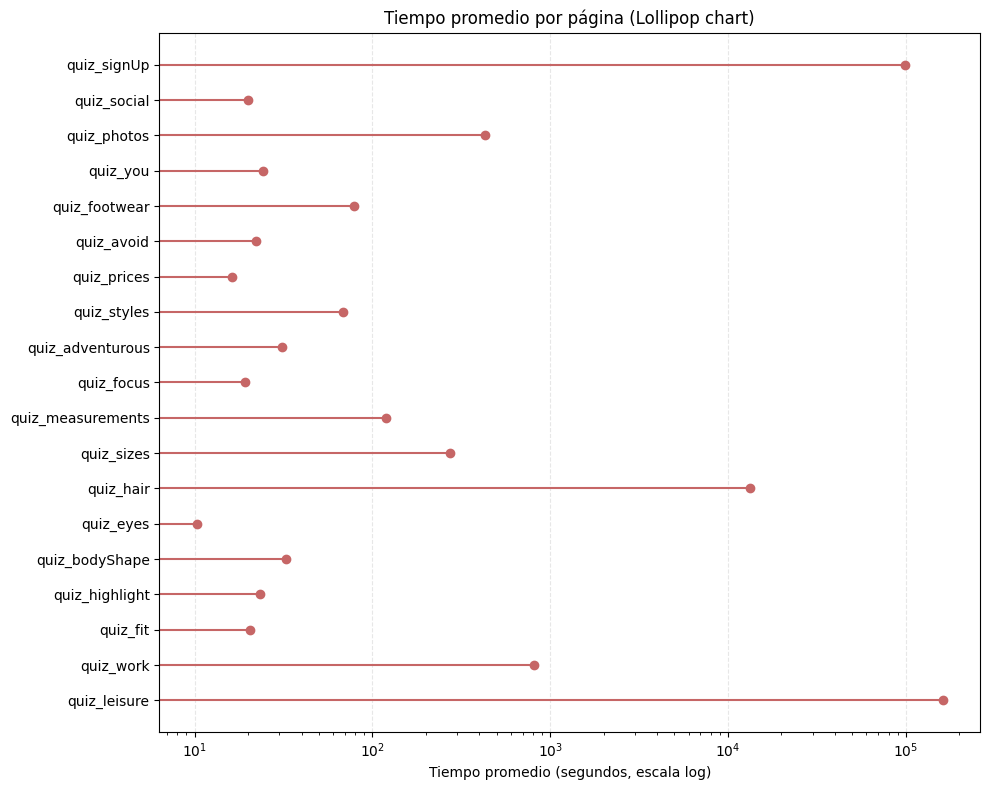

In [24]:
plt.figure(figsize=(10,8))
plt.hlines(times_seconds.index, 0, times_seconds.values, colors="#c66666")
plt.plot(times_seconds.values, times_seconds.index, "o", color="#c66666")
plt.xscale("log")
plt.xlabel("Tiempo promedio (segundos, escala log)")
plt.title("Tiempo promedio por página (Lollipop chart)")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig('../Graficos/Tiempo_promedio_lollipop.png')
plt.show()


In [25]:
# Eliminamos filas sin time_spent porque no aportan al cálculo (últimas páginas por usuario)
df_time = df.dropna(subset=['time_spent']).copy()

# Convertimos a segundos para facilitar gráficos
df_time['time_spent_s'] = df_time['time_spent'].dt.total_seconds()

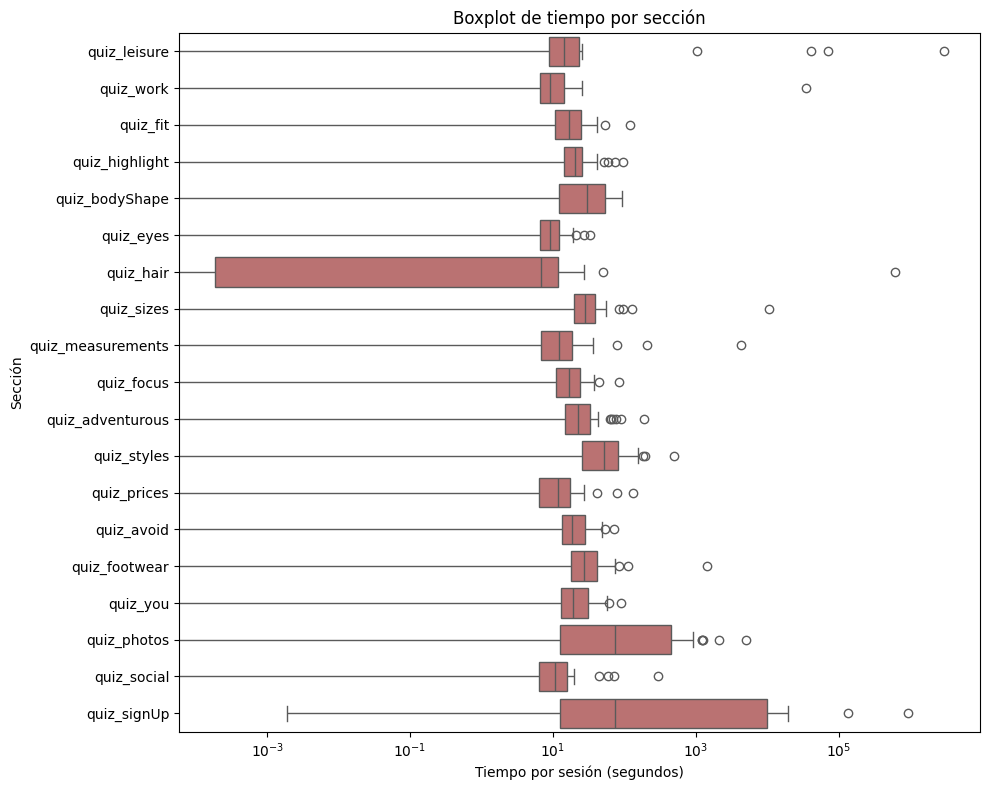

In [26]:
# Filtramos secciones con suficientes observaciones si quieres (por ejemplo >= 5)
counts = df_time['section'].value_counts()
valid_sections = counts[counts >= 5].index.tolist()
df_box = df_time[df_time['section'].isin(valid_sections)].copy()

plt.figure(figsize=(10,8))
# Ordenamos por order lógico
order = [s for s in section_order if s in df_box['section'].unique()]
sns.boxplot(y='section', x='time_spent_s', data=df_box, order=order, color="#c66666")
plt.xlabel("Tiempo por sesión (segundos)")
plt.ylabel("Sección")
plt.title("Boxplot de tiempo por sección")
plt.xscale('log')  # opcional: log-scale para ver outliers sin aplastar
plt.tight_layout()
plt.savefig('../Graficos/Boxplot_timepo.png')
plt.show()


In [27]:
import numpy as np

In [28]:
# que solo coja usuarios que tienen datos de todas las paginas

In [29]:
# Normalizamos nombres (opcional: si hay espacios, mayúsculas, etc)
df['section'] = df['section'].str.strip()

# -------------------------
# 1) Filtrar sólo filas con secciones relevantes (por si hay otras secciones)
# -------------------------
df = df[df['section'].isin(section_order)].copy()

# -------------------------
# 2) Encontrar usuarios que cubren todas las secciones
# -------------------------
# Opción A: usando nunique y comparando con la longitud del section_order
users_counts = df.groupby('user_id')['section'].nunique()
users_all_sections = users_counts[users_counts == len(section_order)].index.tolist()

print(f"Usuarios totales originales: {df['user_id'].nunique()}")
print(f"Usuarios que tienen las {len(section_order)} secciones: {len(users_all_sections)}")

# -------------------------
# 3) Filtrar df para quedarnos sólo con esos usuarios
# -------------------------
df_all_pages = df[df['user_id'].isin(users_all_sections)].copy()

# -------------------------
# 4) (Opcional pero recomendado) -> conservar sólo la PRIMERA visita por usuario x sección
#    Esto facilita análisis secuencia / tiempos entre secciones sin ruido de retrocesos.
# -------------------------
df_first = (
    df_all_pages.sort_values(['user_id', 'event_timestamp_'])
                .drop_duplicates(subset=['user_id', 'section'], keep='first')
                .reset_index(drop=True)
)

# Información final
print(f"Filas originales: {len(df)}")
print(f"Filas tras filtrar usuarios completos: {len(df_all_pages)}")
print(f"Filas tras quedarnos con primera visita por user×section: {len(df_first)}")

# Resultado: df_first es el dataframe limpio listo para análisis secuencial
# Si prefieres mantener todos los eventos (no sólo la primera visita), usa df_all_pages.

Usuarios totales originales: 41
Usuarios que tienen las 19 secciones: 10
Filas originales: 794
Filas tras filtrar usuarios completos: 298
Filas tras quedarnos con primera visita por user×section: 190


In [30]:
# hacer grafico funnel

MEDIAN TIMES:
section
quiz_photos         75.229311
quiz_signUp         74.152804
quiz_styles         51.587092
quiz_bodyShape      30.371002
quiz_sizes          28.350611
quiz_footwear       27.532795
quiz_adventurous    22.807763
quiz_highlight      20.634527
quiz_you            19.043753
quiz_avoid          18.498041
Name: time_spent, dtype: float64

RETROCESSIONS:
section
quiz_styles         5
quiz_signUp         3
quiz_prices         3
quiz_adventurous    3
quiz_sizes          3
quiz_highlight      2
quiz_hair           2
quiz_leisure        2
quiz_fit            2
quiz_bodyShape      2
Name: count, dtype: int64

DROP-OFFS:
section
quiz_signUp     32
quiz_leisure     5
quiz_social      2
quiz_fit         1
quiz_work        1
Name: count, dtype: int64


C:\Users\Martin\AppData\Local\Temp\ipykernel_14684\1191862438.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_time.values, y=median_time.index, palette="Reds_r")


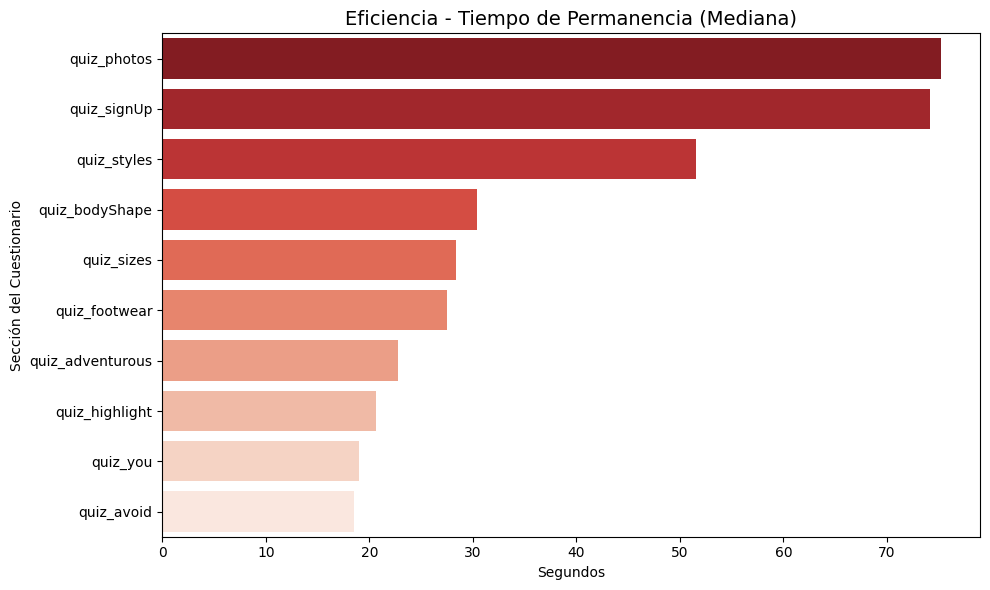

C:\Users\Martin\AppData\Local\Temp\ipykernel_14684\1191862438.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retro_counts.values, y=retro_counts.index, palette="Oranges_r")


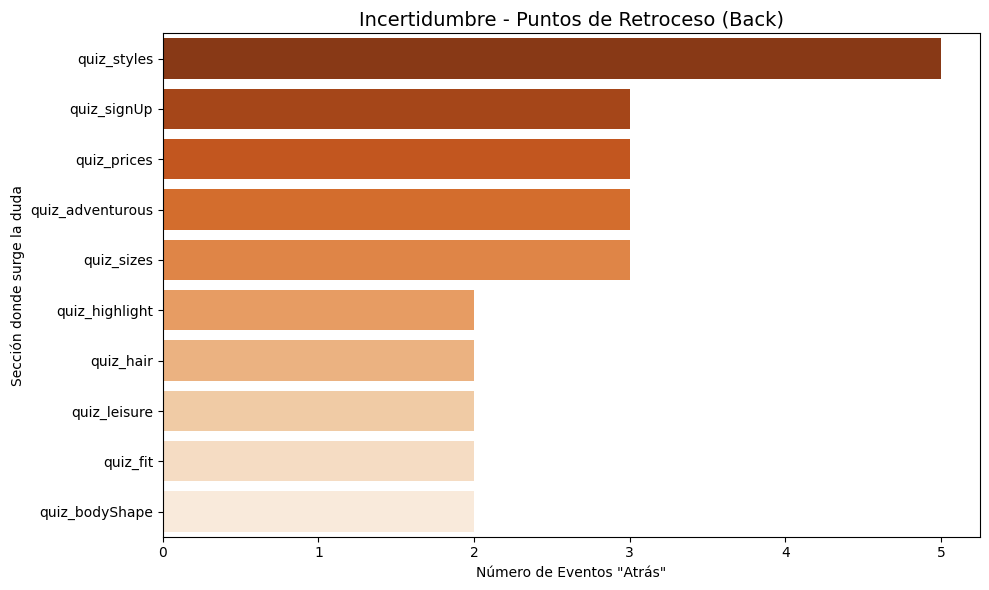

C:\Users\Martin\AppData\Local\Temp\ipykernel_14684\1191862438.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=drop_offs.values, y=drop_offs.index, palette=custom_palette)


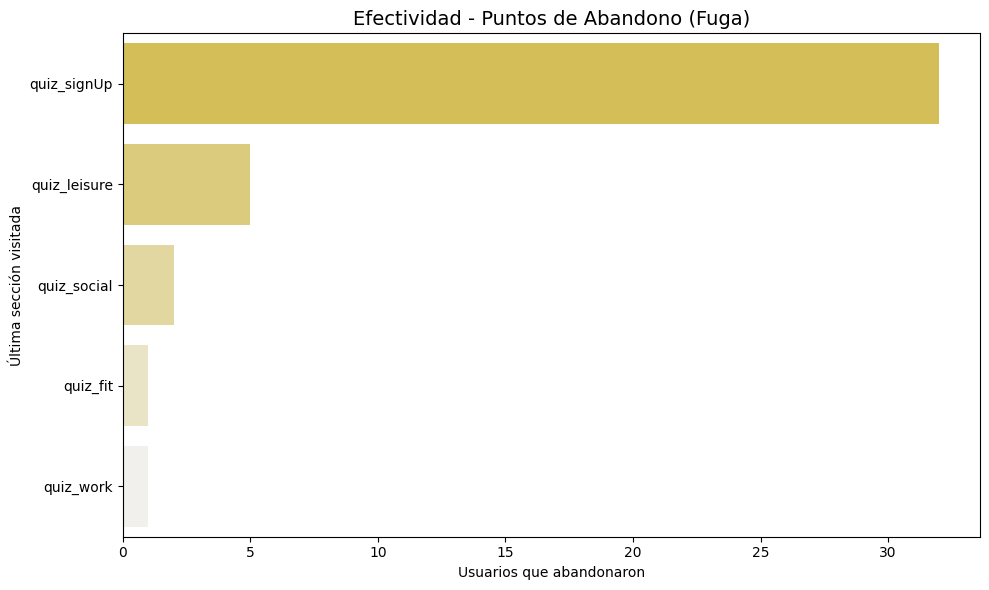

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../Datos/Originales/Datos_UX/page_views_2.csv', sep=';')
df['event_timestamp_'] = pd.to_datetime(df['event_timestamp_'])
df = df.sort_values(['user_id', 'event_timestamp_'])

# 1. Time Spent (Median)
df['next_timestamp'] = df.groupby('user_id')['event_timestamp_'].shift(-1)
df['time_spent'] = (df['next_timestamp'] - df['event_timestamp_']).dt.total_seconds()
# Filter out unreasonable times (e.g. > 10 min) just for clean viz, or keep all median is robust.
median_time = df.groupby('section')['time_spent'].median().sort_values(ascending=False).head(10)

# 2. Retrocessions (Back button)
df['prev_section'] = df.groupby('user_id')['section'].shift(1)
df['next_section'] = df.groupby('user_id')['section'].shift(-1)
# Logic: Prev == Next means User was at A, went to B (current row), then went back to A.
# The "Retrocession" event happens at section B (current row) because from B they go back to A.
# Wait, if Prev=A, Curr=B, Next=A. The user is at B. They go to A. So the "Back" action is taken at B.
retrocessions = df[df['prev_section'] == df['next_section']]
retro_counts = retrocessions['section'].value_counts().head(10)

# 3. Drop-offs
last_events = df.groupby('user_id').tail(1)
drop_offs = last_events['section'].value_counts().head(10)

# Print values to use in text
print("MEDIAN TIMES:")
print(median_time)
print("\nRETROCESSIONS:")
print(retro_counts)
print("\nDROP-OFFS:")
print(drop_offs)

# Plot 1: Time
plt.figure(figsize=(10, 6))
sns.barplot(x=median_time.values, y=median_time.index, palette="Reds_r")
plt.title('Eficiencia - Tiempo de Permanencia (Mediana)', fontsize=14)
plt.xlabel('Segundos')
plt.ylabel('Sección del Cuestionario')
plt.tight_layout()
plt.savefig('../Graficos/Permananecia.png')
plt.show()

# Plot 2: Retrocessions
plt.figure(figsize=(10, 6))
sns.barplot(x=retro_counts.values, y=retro_counts.index, palette="Oranges_r")
plt.title('Incertidumbre - Puntos de Retroceso (Back)', fontsize=14)
plt.xlabel('Número de Eventos "Atrás"')
plt.ylabel('Sección donde surge la duda')
plt.tight_layout()
plt.savefig('../Graficos/Retroceso.png')
plt.show()

# Plot 3: Drop-offs
custom_palette = sns.light_palette(colores["amarillo"], n_colors=len(drop_offs), reverse=True)

plt.figure(figsize=(10, 6))

# Generar el gráfico usando la paleta personalizada
sns.barplot(x=drop_offs.values, y=drop_offs.index, palette=custom_palette)

plt.title('Efectividad - Puntos de Abandono (Fuga)', fontsize=14)
plt.xlabel('Usuarios que abandonaron')
plt.ylabel('Última sección visitada')

plt.tight_layout()
plt.savefig('../Graficos/AbAandono.png')
plt.show()